# Plot from `evaluate_mmd.py` outputs (OnsagerReg variants)

Loads `outputs/mmd_summary_OnsagerReg_dt<DT>.npz` produced by `run_reg.sh` and
renders the MMD-vs-time figure and the structural-error bar chart for the
regularized OnsagerNet variants (L2 and Sobolev at different weights).

Layout mirrors `nonlinear_plot.ipynb` so the two notebooks can be compared
side by side.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

MODEL_NAMES = [
    "OnsagerRegL21e-3",
    "OnsagerRegL21e-4",
    "OnsagerRegSobolev1e-3",
    "OnsagerRegSobolev1e-4",
]
MODEL_DISPLAY = {
    "OnsagerRegL21e-3":        r"$L^2 (10^{-3}$)",
    "OnsagerRegL21e-4":        r"$L^2 (10^{-4}$)",
    "OnsagerRegSobolev1e-3":   r"Sobolev ($10^{-3}$)",
    "OnsagerRegSobolev1e-4":   r"Sobolev ($10^{-4}$)",
}
MODEL_COLORS = {
    "OnsagerRegL21e-3":        "tab:purple",
    "OnsagerRegL21e-4":        "tab:pink",
    "OnsagerRegSobolev1e-3":   "tab:brown",
    "OnsagerRegSobolev1e-4":   "tab:olive",
}
METRIC_KEYS = ["drift", "gradV", "MgradV", "WgradV"]
METRIC_TITLES = {
    "drift":   r"drift rel err",
    "gradV":   r"$\nabla V$ rel err",
    "MgradV":  r"$M\,\nabla V$ rel err",
    "WgradV":  r"$W\,\nabla V$ rel err",
}

def load_npz(path):
    """Load mmd_summary npz; return dict of arrays."""
    return dict(np.load(path, allow_pickle=False))

def per_seed_curves(data, model):
    """Return {seed: mmd_curve} from npz keys like '<model>_seed<seed>'."""
    out = {}
    prefix = f"{model}_seed"
    for k, v in data.items():
        if k.startswith(prefix) and not k.startswith("err_"):
            try:
                out[int(k[len(prefix):])] = v
            except ValueError:
                pass
    return out

In [2]:
# Pick which run to plot.
DT = 0.01      # 0.01 or 0.005
npz_path = f"outputs/mmd_summary_OnsagerReg_dt{DT}.npz"
data = load_npz(npz_path)

ts = data["ts"]
mmd_ref = data["mmd_ref"]
bandwidth = float(data["bandwidth"])
kappa = float(data["kappa"])
dt = float(data["dt"])

print(f"Loaded {npz_path}")
print(f"  dt={dt}, kappa={kappa}, bandwidth={bandwidth:.4g}, len(ts)={len(ts)}")
for m in MODEL_NAMES:
    seeds = sorted(per_seed_curves(data, m).keys())
    print(f"  {m}: seeds={seeds}")

Loaded outputs/mmd_summary_OnsagerReg_dt0.01.npz
  dt=0.01, kappa=0.8, bandwidth=0.9776, len(ts)=200
  OnsagerRegL21e-3: seeds=[0, 1, 12, 123, 1234]
  OnsagerRegL21e-4: seeds=[0, 1, 12, 123, 1234]
  OnsagerRegSobolev1e-3: seeds=[0, 1, 12, 123, 1234]
  OnsagerRegSobolev1e-4: seeds=[0, 1, 12, 123, 1234]


## MMD² vs time

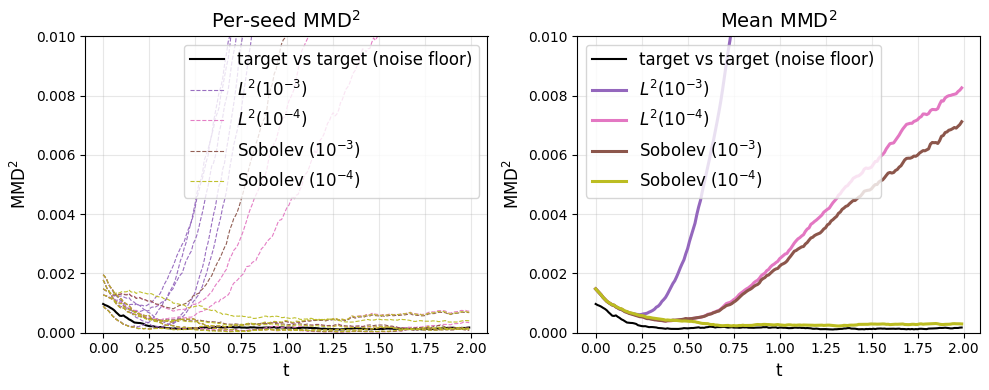

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
yscale = "linear"
for ax in axes:
    ref = mmd_ref if yscale == "linear" else np.where(mmd_ref > 0, mmd_ref, np.nan)
    ax.plot(ts, ref, color="k", lw=1.5,
            label="target vs target (noise floor)")
for model in MODEL_NAMES:
    ax = axes[0]
    mean_key = f"{model}_mean"
    if mean_key not in data:
        continue
    color = MODEL_COLORS[model]
    mean = data[mean_key]
    std = data[f"{model}_std"]
    n_seeds = int(data[f"{model}_n_seeds"])
    seeds = sorted(per_seed_curves(data, model).keys())
    label_disp = MODEL_DISPLAY.get(model, model)
    # thin per-seed traces
    for seed, curve in sorted(per_seed_curves(data, model).items()):
        c = curve if yscale == "linear" else np.where(curve > 0, curve, np.nan)
        label = label_disp if seed == seeds[0] else None
        ax.plot(ts, c, color=color, lw=0.8, ls="--", alpha=0.95, label=label)
    # mean curve
    ax = axes[1]
    m_plot = mean if yscale == "linear" else np.where(mean > 0, mean, np.nan)
    ax.plot(ts, m_plot, color=color, lw=2.2,
            label=label_disp, ls="-")

for ax in axes:
    ax.set_xlabel("t", fontsize=12)
    ax.set_ylabel(r"MMD$^2$", fontsize=12)
    ax.set_yscale(yscale)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(loc="best", fontsize=12)
    ax.set_ylim(0,0.01)


axes[0].set_title(f"Per-seed MMD$^2$", fontsize=14)
axes[1].set_title(f"Mean MMD$^2$", fontsize=14)
fig.tight_layout()
fig.savefig(f"mmd_vs_time_OnsagerReg_dt{dt}.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Structural error bar chart

=== Structural relative errors -- OnsagerReg variants (dt=0.01, kappa=0.8) ===
metric   model                       mean        std  per-seed values
---------------------------------------------------------------------
drift    OnsagerRegL21e-3       1.646e-01   1.66e-03  s0=1.656e-01  s1=1.649e-01  s12=1.669e-01  s123=1.621e-01  s1234=1.633e-01
drift    OnsagerRegL21e-4       7.260e-02   3.21e-02  s0=5.168e-02  s1=4.400e-02  s12=4.470e-02  s123=1.033e-01  s1234=1.193e-01
drift    OnsagerRegSobolev1e-3   6.539e-02   3.72e-02  s0=4.595e-02  s1=4.134e-02  s12=4.916e-02  s123=5.108e-02  s1234=1.394e-01
drift    OnsagerRegSobolev1e-4   4.662e-02   1.47e-03  s0=4.695e-02  s1=4.442e-02  s12=4.640e-02  s123=4.631e-02  s1234=4.901e-02

gradV    OnsagerRegL21e-3       9.997e-01   6.78e-05  s0=9.996e-01  s1=9.998e-01  s12=9.996e-01  s123=9.997e-01  s1234=9.997e-01
gradV    OnsagerRegL21e-4       9.986e-01   3.26e-04  s0=9.986e-01  s1=9.985e-01  s12=9.980e-01  s123=9.991e-01  s1234=9.986e-01
grad

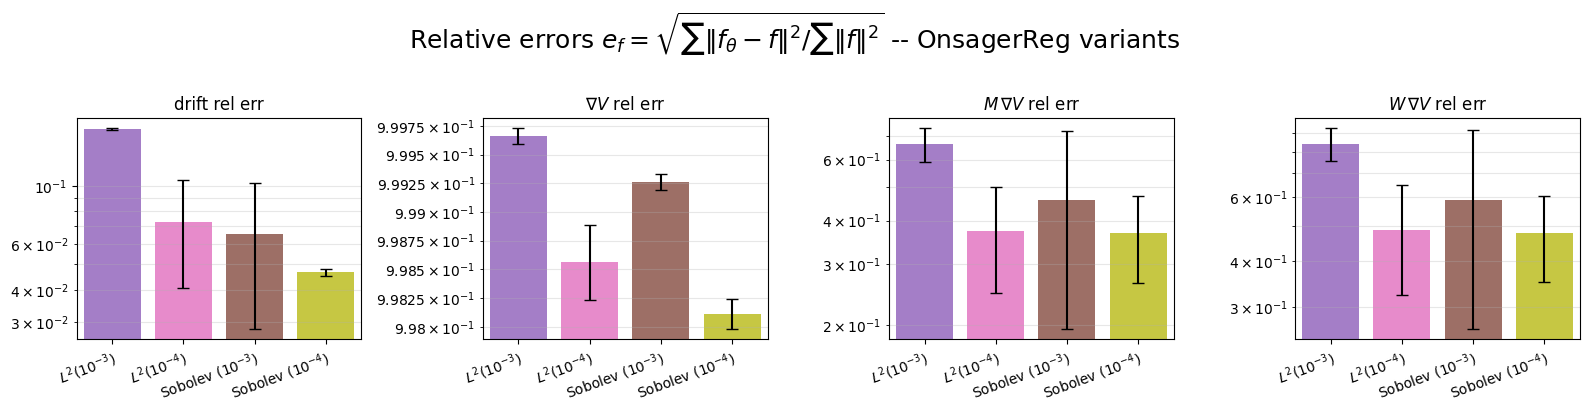

In [4]:
# Print all per-seed and aggregated relative errors before plotting.
print(f"=== Structural relative errors -- OnsagerReg variants (dt={dt}, kappa={kappa}) ===")
header = f"{'metric':<8} {'model':<20} {'mean':>11}  {'std':>9}  per-seed values"
print(header)
print("-" * len(header))
for k in METRIC_KEYS:
    for m in MODEL_NAMES:
        mean_key = f"err_{m}_{k}_mean"
        if mean_key not in data:
            continue
        mean = float(data[mean_key])
        std = float(data[f"err_{m}_{k}_std"])
        seeds = sorted(per_seed_curves(data, m).keys())
        per_seed_vals = []
        for s in seeds:
            v = data.get(f"err_{m}_seed{s}_{k}")
            if v is not None:
                per_seed_vals.append((s, float(v)))
        seeds_str = "  ".join(f"s{s}={v:.3e}" for s, v in per_seed_vals)
        print(f"{k:<8} {m:<20} {mean:>11.3e}  {std:>9.2e}  {seeds_str}")
    print()

fig2, axes2 = plt.subplots(1, 4, figsize=(16, 4))
for ax, k in zip(axes2, METRIC_KEYS):
    means, stds, labels, colors = [], [], [], []
    for m in MODEL_NAMES:
        mean_key = f"err_{m}_{k}_mean"
        if mean_key not in data:
            continue
        means.append(float(data[mean_key]))
        stds.append(float(data[f"err_{m}_{k}_std"]))
        labels.append(MODEL_DISPLAY.get(m, m))
        colors.append(MODEL_COLORS[m])
    if not means:
        ax.set_axis_off()
        ax.set_title(METRIC_TITLES[k] + " (no data)")
        continue
    xs = np.arange(len(labels))
    ax.bar(xs, means, yerr=stds, color=colors, alpha=0.85, capsize=4)
    ax.set_xlim(-0.5, len(labels) - 0.5)
    ax.set_xticks(xs)
    ax.set_xticklabels(labels, rotation=20, ha="right", rotation_mode="anchor")
    ax.set_yscale("log")
    ax.set_title(METRIC_TITLES[k])
    ax.grid(True, which="both", alpha=0.3, axis="y")
fig2.suptitle(
    rf"Relative errors $e_f=\sqrt{{\sum\|f_\theta-f\|^2/\sum\|f\|^2}}$ -- OnsagerReg variants",
    y=1.02, fontsize=18,
)
fig2.tight_layout()
# fig2.savefig(f"metrics_OnsagerReg_dt{dt}.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Optional: overlay vanilla Onsager from the main run
Uses `outputs/mmd_summary_dt<DT>.npz` (produced by `eval.sh` / the main
`evaluate_mmd.py` call) to add vanilla Onsager mean curve as a baseline.

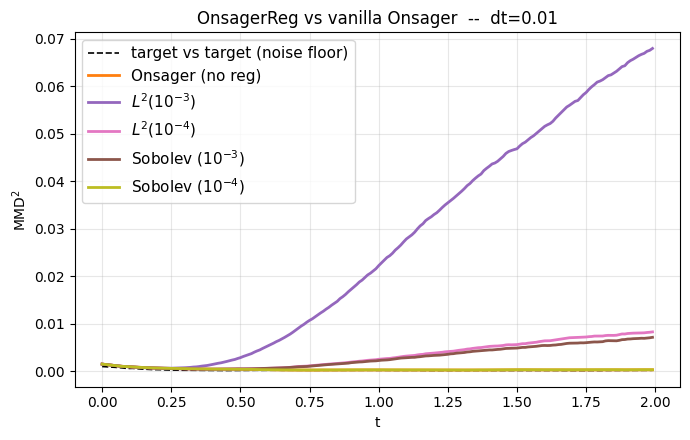

In [5]:
main_path = f"outputs/mmd_summary_dt{DT}.npz"
if not os.path.isfile(main_path):
    print(f"skip: {main_path} not found (run eval.sh first to generate it)")
else:
    main_data = load_npz(main_path)
    fig3, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(ts, mmd_ref, color="k", lw=1.2, ls="--",
            label="target vs target (noise floor)")
    if "Onsager_mean" in main_data:
        ax.plot(main_data["ts"], main_data["Onsager_mean"],
                color="tab:orange", lw=2.0, label="Onsager (no reg)")
    for m in MODEL_NAMES:
        if f"{m}_mean" not in data:
            continue
        ax.plot(ts, data[f"{m}_mean"], color=MODEL_COLORS[m], lw=2.0,
                label=MODEL_DISPLAY.get(m, m))
    ax.set_xlabel("t")
    ax.set_ylabel(r"MMD$^2$")
    ax.set_yscale("linear")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=11)
    ax.set_title(f"OnsagerReg vs vanilla Onsager  --  dt={dt}")
    fig3.tight_layout()
    # fig3.savefig(f"mmd_vs_time_OnsagerReg_vs_Onsager_dt{dt}.pdf", dpi=300, bbox_inches="tight")
    plt.show()

### Tweaking tips
- Display name: edit `MODEL_DISPLAY` in the imports cell.
- Color: edit `MODEL_COLORS`.
- log y: change `yscale = "log"` in the MMD plotting cell.
- Save: uncomment the `fig*.savefig(...)` lines.
- All raw numbers are in `data` -- `print(sorted(data.keys()))` to see everything.